<!-- STANDIN notebook title -->
# Part notebook: supervised models and their explanations (steps A4–A6, B1, B2, B5, B6, C1, C2)

Owner: Kirill. This title and the stand-in cells are dropped by `tools/assemble.py`.

In [1]:
# STANDIN A1-A3
%run 00_setup.ipynb

(11430, 89)
status
legitimate    5715
phishing      5715
Name: count, dtype: int64


6858 2286 2286
train      phishing share: 0.500
validation phishing share: 0.500
test       phishing share: 0.500


<!-- STEP A4 -->
### 5.1 Supervised: all labels

## Step A4: Glass box 1: a small decision tree

We try depth 3 and 4 and keep the better one on the **validation** set (never on test). We read the
tree in step B1.

In [2]:
# STEP A4
from sklearn.tree import DecisionTreeClassifier, export_text

best_score, tree = -1, None
depth_scores = []                                  # both depths, for the report
for depth in [3, 4]:
    t = DecisionTreeClassifier(max_depth=depth, random_state=42)
    t.fit(X_train, y_train)
    scores = report(t, X_val, y_val)
    score = scores["macro_F1"]                     # choose on VALIDATION
    print("depth", depth, "validation macro-F1:", round(score, 3))
    depth_scores.append({"max_depth": depth, "leaves": t.get_n_leaves(), **scores})
    if score > best_score:
        best_score, tree = score, t
print("kept depth", tree.get_depth())

depth_scores = pd.DataFrame(depth_scores)
depth_scores.to_csv("results/tables/A4_tree_depth.csv", index=False)
depth_scores

depth 3 validation macro-F1: 0.913


depth 4 validation macro-F1: 0.925
kept depth 4


,max_depth,leaves,macro_F1,recall,ROC_AUC,FAR
0,3,8,0.913,0.904,0.948,0.079
1,4,16,0.925,0.920,0.954,0.070


<!-- STEP A5 -->
## Step A5: Glass box 2: logistic regression

One weight per feature. We scale the features first so the weights can be compared; the `Pipeline`
fits the scaler on training data only.

In [3]:
# STEP A5
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# The Pipeline fits the scaler on training data only. No leakage.
logreg = Pipeline([
    ("scale", StandardScaler()),
    ("lr", LogisticRegression(max_iter=1000)),
])
logreg.fit(X_train, y_train)
print(report(logreg, X_val, y_val))

{'macro_F1': 0.938, 'recall': 0.933, 'ROC_AUC': 0.983, 'FAR': 0.056}


<!-- STEP A6 -->
## Step A6: The black box: a Random Forest

300 trees trained on all labels. This is the **upper line**: the best we can hope for when every URL
is labelled.

In [4]:
# STEP A6
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
print(report(rf, X_val, y_val))

{'macro_F1': 0.961, 'recall': 0.968, 'ROC_AUC': 0.993, 'FAR': 0.046}


<!-- STEP B1 -->
# 6. Part B: Explain the detectors

## Step B1: Read the glass boxes

The tree and the logistic regression need no SHAP or LIME: the model itself is the explanation.
In the tree, each `|---` line is a yes/no question and `class: 1` means phishing. In the logistic
regression, a positive weight pushes toward phishing (the features are scaled, so the weights can be
compared).

In [5]:
# STEP B1
# Glass box 1: the tree, printed as rules
tree_rules = export_text(tree, feature_names=list(X_train.columns))
print(tree_rules)
print("tree leaves:", tree.get_n_leaves())
with open("results/tables/B1_tree_rules.txt", "w") as f:
    f.write(tree_rules)

# Glass box 2: one weight per feature. Positive = pushes toward phishing.
w = pd.Series(logreg.named_steps["lr"].coef_[0], index=X_train.columns)
top10 = w.abs().sort_values(ascending=False).index[:10]
print(w[top10].round(3))
print("logreg weights with |w| > 0.01:", int((w.abs() > 0.01).sum()))
w[top10].round(3).rename("weight").to_csv("results/tables/B1_logreg_top10_weights.csv")

|--- google_index <= 0.50
|   |--- page_rank <= 0.50
|   |   |--- shortest_word_path <= 0.50
|   |   |   |--- nb_www <= 0.50
|   |   |   |   |--- class: 1
|   |   |   |--- nb_www >  0.50
|   |   |   |   |--- class: 0
|   |   |--- shortest_word_path >  0.50
|   |   |   |--- nb_hyphens <= 4.50
|   |   |   |   |--- class: 1
|   |   |   |--- nb_hyphens >  4.50
|   |   |   |   |--- class: 0
|   |--- page_rank >  0.50
|   |   |--- nb_qm <= 0.50
|   |   |   |--- phish_hints <= 1.50
|   |   |   |   |--- class: 0
|   |   |   |--- phish_hints >  1.50
|   |   |   |   |--- class: 1
|   |   |--- nb_qm >  0.50
|   |   |   |--- nb_hyperlinks <= 32.50
|   |   |   |   |--- class: 1
|   |   |   |--- nb_hyperlinks >  32.50
|   |   |   |   |--- class: 0
|--- google_index >  0.50
|   |--- page_rank <= 2.50
|   |   |--- domain_in_brand <= 0.50
|   |   |   |--- ratio_extRedirection <= 1.58
|   |   |   |   |--- class: 1
|   |   |   |--- ratio_extRedirection >  1.58
|   |   |   |   |--- class: 0
|   |   |--- d

<!-- STEP B1 -->
**What we see**

- **The tree's first question, in plain English:** *"Has Google indexed this page?"*
  (`google_index <= 0.5` means yes, indexed). Every URL is first split on that. It makes sense to a
  security person: a phishing page lives for days and is rarely indexed. In the whole dataset, 84% of
  the non-indexed URLs are phishing and only 11% of the indexed ones. The second question on both
  branches is `page_rank`: how well-linked the site is.
- The tree has 16 leaves, so any decision can be read as at most 4 yes/no questions. Some leaves are
  less obvious, e.g. "not indexed, page rank above 2.5, more than 36 links and `web_traffic` at most
  4.5 → phishing", where `web_traffic` 0 means "no rank found".
- **Logistic regression:** 79 of the 87 weights have |w| > 0.01, so this "glass box" uses almost every
  feature, which makes it much harder to read than its top 10 suggests. Its strongest weight is
  `longest_words_raw` (+2.95, long words in the URL push toward phishing). `page_rank` (−1.70) and
  `google_index` (+1.54) point the same way as in the tree. Some signs are surprising, e.g. `nb_hyphens`
  is negative: a weight shows a feature's effect with all other features held fixed, and many features
  are correlated.

<!-- STEP B2 -->
## Step B2: SHAP for the supervised forest (global)

SHAP gives values for both classes, so we keep class 1 (phishing) with `sv[:, :, 1]`. The bar plot
shows the average push of each feature; the beeswarm shows one dot per URL (red = high value,
right = toward phishing). `shap_top` is also the ranking used to choose the BRB features in step D1.

(500, 87, 2)


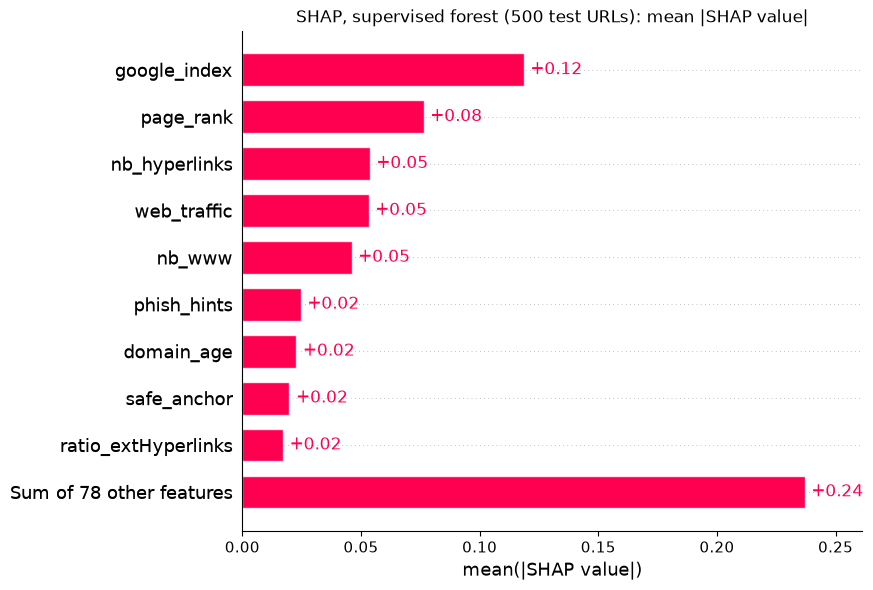

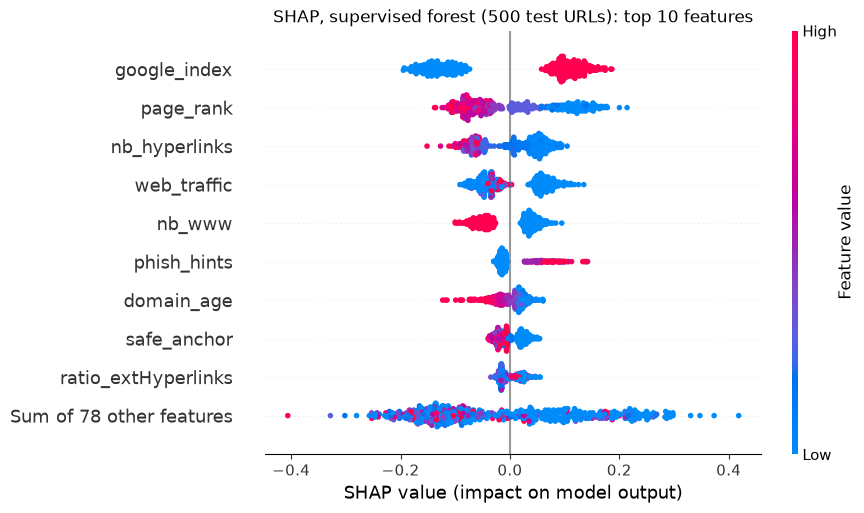

google_index            0.1186
page_rank               0.0764
nb_hyperlinks           0.0537
web_traffic             0.0532
nb_www                  0.0460
phish_hints             0.0246
domain_age              0.0227
safe_anchor             0.0199
ratio_extHyperlinks     0.0171
ratio_extRedirection    0.0142
dtype: float64


In [6]:
# STEP B2
import shap
import matplotlib.pyplot as plt

explainer = shap.TreeExplainer(rf)
sv = explainer(X_test.iloc[:500])         # 500 test URLs is plenty
print(sv.values.shape)                    # (500, 87, 2) = URLs, features, classes
assert sv.values.shape == (500, 87, 2)
sv1 = sv[:, :, 1]                         # keep class 1 = phishing

shap.plots.bar(sv1, max_display=10, show=False)        # average push of each feature
plt.title("SHAP, supervised forest (500 test URLs): mean |SHAP value|")
plt.savefig("results/figures/B2_shap_forest_bar.png", dpi=150, bbox_inches="tight")
plt.show()
shap.plots.beeswarm(sv1, max_display=10, show=False)   # one dot per URL
plt.title("SHAP, supervised forest (500 test URLs): top 10 features")
plt.savefig("results/figures/B2_shap_forest_beeswarm.png", dpi=150, bbox_inches="tight")
plt.show()

shap_top = pd.Series(np.abs(sv1.values).mean(axis=0),
                     index=X_test.columns).sort_values(ascending=False)
print(shap_top.head(10).round(4))
shap_top.rename("mean_abs_shap").rename_axis("feature").to_csv("results/tables/B2_shap_top.csv")

<!-- STEP B2 -->
**What we see**

- **The top feature is `google_index`, and its red dots are on the right.** Red = high value = 1 =
  Google has **not** indexed the page, and right = toward phishing. In plain words: "not indexed by
  Google" is the forest's strongest single reason to call a URL phishing, and "indexed" (blue, left)
  its strongest reason to call it legitimate.
- The next features read the same way: a **low** `page_rank` (blue) and **few** links (`nb_hyperlinks`,
  blue) push toward phishing, and a **low** `web_traffic` pushes toward phishing too, because 0 means
  "no traffic rank found" (81% of those URLs are phishing). More phishing words (`phish_hints`, red)
  push toward phishing; a young domain (`domain_age`, blue) slightly so.
- Three of the top four features (`google_index`, `page_rank`, `web_traffic`) are **external lookups**.
  Step C1 tests what happens without them.

<!-- STEP B5 -->
## Step B5: Pick three URLs to explain

The phishing URL the forest is most sure about, the legitimate URL it is most sure about, and its most
confident mistake (mistakes teach the most). The numbers `i_phish`, `i_legit` and `i_wrong` are
**positions** in `X_test` (use `.iloc`).

In [7]:
# STEP B5
prob = rf.predict_proba(X_test)[:, 1]       # P(phishing) for every test URL
pred = (prob >= 0.5).astype(int)
yt = y_test.values

# the surest correct phishing alert
caught = np.where((yt == 1) & (pred == 1))[0]
i_phish = caught[np.argmax(prob[caught])]

# the surest correct legitimate URL
ok_legit = np.where((yt == 0) & (pred == 0))[0]
i_legit = ok_legit[np.argmin(prob[ok_legit])]

# the most confident mistake (or the least sure URL if there is no mistake)
wrong = np.where(yt != pred)[0]
if len(wrong) > 0:
    i_wrong = wrong[np.argmax(np.abs(prob[wrong] - 0.5))]
else:
    i_wrong = np.argmin(np.abs(prob - 0.5))

three = [("phishing", i_phish), ("legitimate", i_legit), ("wrong", i_wrong)]
for name, i in three:
    print(f"{name:10s} row {i}: P(phishing) = {prob[i]:.3f},",
          f"true label = {yt[i]}")

# The raw URL text of each, so we can say what the mistake looked like
three_urls = pd.DataFrame([{"name": name, "position": int(i), "P_phishing": round(float(prob[i]), 3),
                            "true_label": int(yt[i]), "url": df.loc[X_test.index[i], "url"]}
                           for name, i in three])
print("test mistakes in total:", len(wrong), "of", len(yt))
three_urls.to_csv("results/tables/B5_three_urls.csv", index=False)
three_urls

phishing   row 34: P(phishing) = 1.000, true label = 1
legitimate row 10: P(phishing) = 0.000, true label = 0
wrong      row 1257: P(phishing) = 0.950, true label = 0
test mistakes in total: 80 of 2286


,name,position,P_phishing,true_label,url
0,phishing,34,1.00,1,https://support-appleld.com.secureupdate.duila...
1,legitimate,10,0.00,0,http://en.academic.ru/dic.nsf/enwiki/100376
2,wrong,1257,0.95,0,http://graphicsfairy.blogspot.ru/


<!-- STEP B5 -->
**What we see**

The forest makes 80 mistakes on the 2,286 test URLs. The three URLs:

- **Phishing** (row 34, P = 1.000): `https://support-appleld.com.secureupdate.duilawyeryork.com/ap/...`
  — a fake Apple support address ("appleld" with a lower-case L) on someone else's domain.
- **Legitimate** (row 10, P = 0.000): `http://en.academic.ru/dic.nsf/enwiki/100376`.
- **Most confident mistake** (row 1257, P = 0.950, truly legitimate):
  `http://graphicsfairy.blogspot.ru/` — a real blog on Google's free Blogspot service.

<!-- STEP B6 -->
## Step B6: Local explanations with SHAP and LIME

For each of the three URLs: a SHAP waterfall (from the base value to this URL's score, feature by
feature) and a LIME chart (a straight line fitted around this URL). Red/right (SHAP) and positive
weights (LIME) push toward phishing. A LIME fit score below 0.5 means the line copies the model badly:
do not trust that explanation much.

phishing


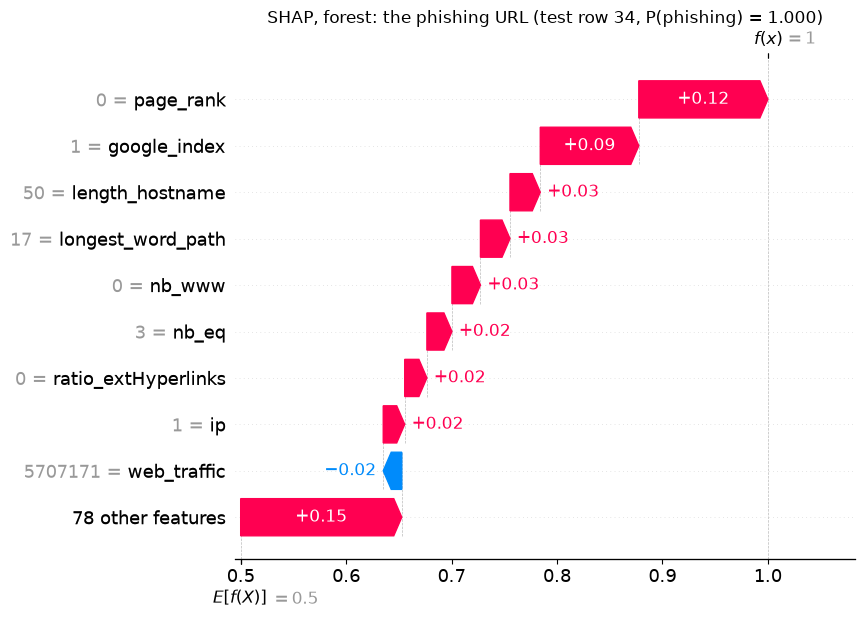

legitimate


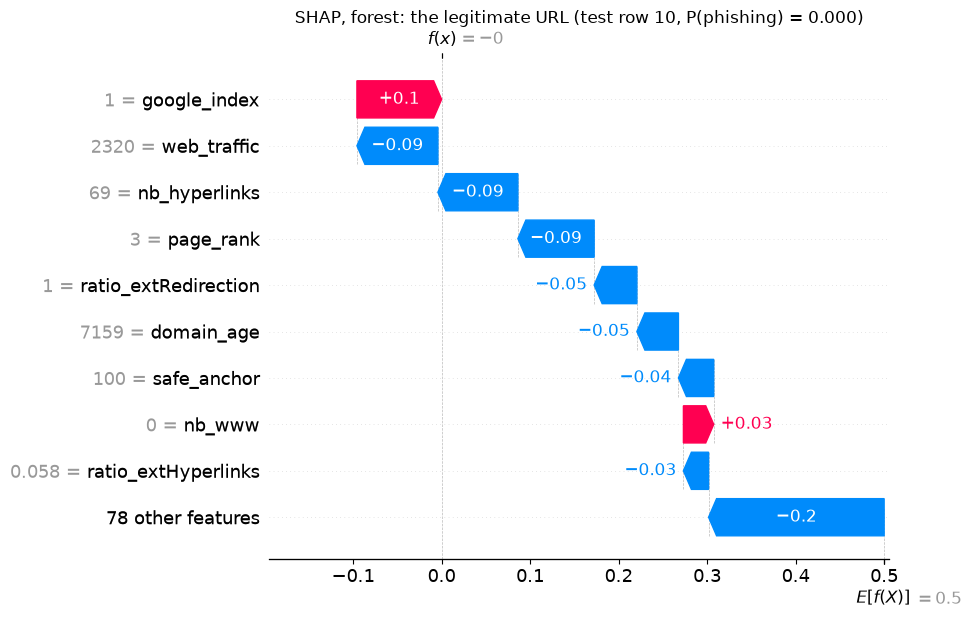

wrong


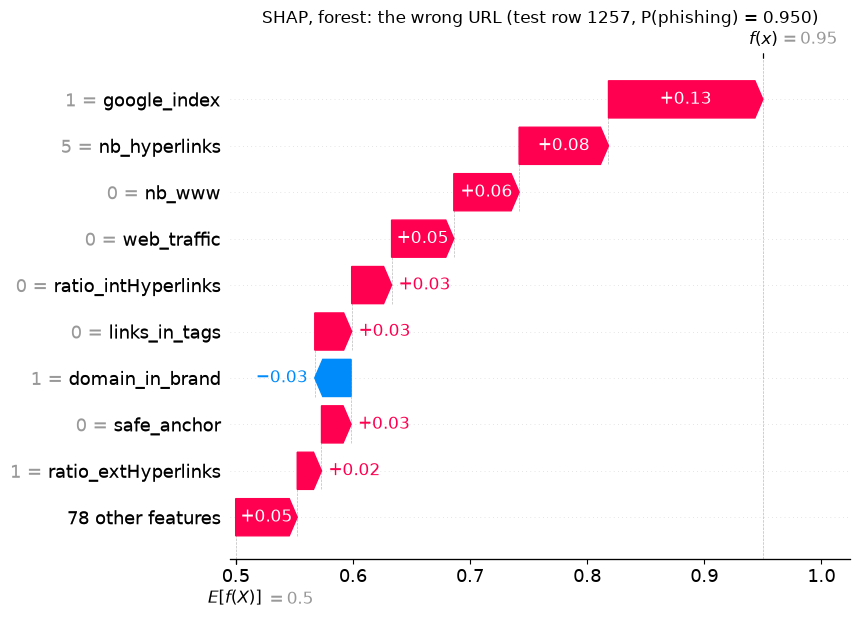

In [8]:
# STEP B6
for name, i in three:
    one = explainer(X_test.iloc[[i]])[:, :, 1]     # this URL, class phishing
    print(name)
    shap.plots.waterfall(one[0], max_display=10, show=False)
    plt.title(f"SHAP, forest: the {name} URL (test row {i}, P(phishing) = {prob[i]:.3f})")
    plt.savefig(f"results/figures/B6_shap_waterfall_{name}.png", dpi=150, bbox_inches="tight")
    plt.show()

phishing - fit score: 0.63 
   0.00 < google_index <= 1.00  +0.188
   page_rank <= 1.00            +0.161
   nb_www <= 0.00               +0.085
   phish_hints <= 0.00          -0.078
   longest_word_path > 11.00    +0.044
   right_clic <= 0.00           -0.026
   path_extension <= 0.00       +0.020
   punycode <= 0.00             -0.016


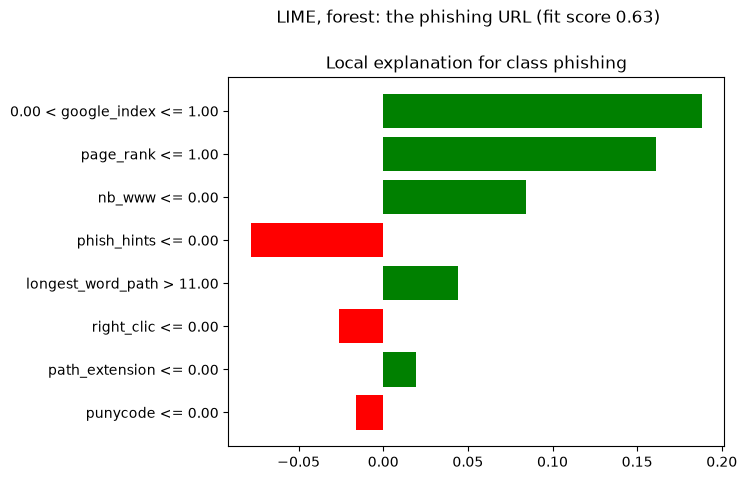

legitimate - fit score: 0.42    <- below 0.5: do not trust it much
   0.00 < google_index <= 1.00  +0.191
   iframe <= 0.00               -0.097
   nb_www <= 0.00               +0.080
   phish_hints <= 0.00          -0.073
   nb_star <= 0.00              -0.055
   nb_external_redirection <= 0.00 +0.052
   domain_age > 7025.25         -0.046
   nb_comma <= 0.00             -0.043


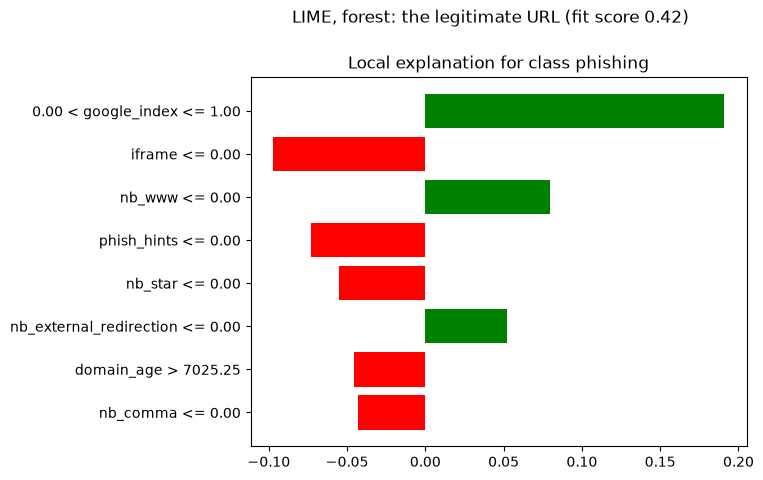

wrong - fit score: 0.48    <- below 0.5: do not trust it much
   0.00 < google_index <= 1.00  +0.186
   nb_www <= 0.00               +0.085
   web_traffic <= 0.00          +0.075
   phish_hints <= 0.00          -0.070
   nb_hyperlinks <= 8.00        +0.068
   punycode <= 0.00             +0.063
   nb_star <= 0.00              -0.053
   nb_dollar <= 0.00            -0.051


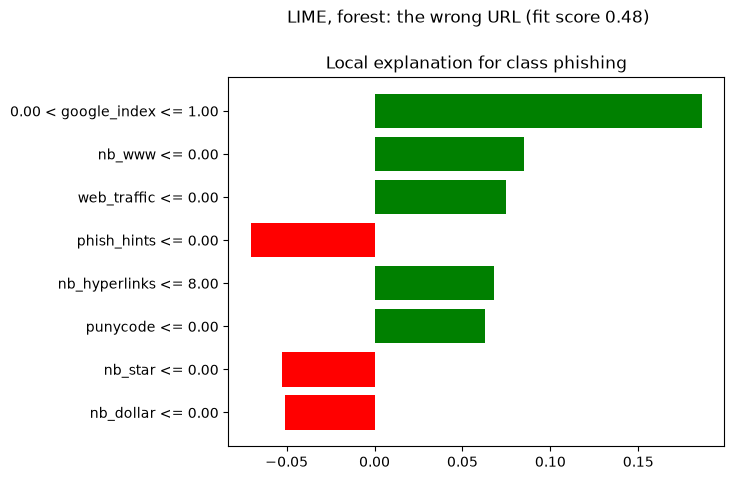

In [9]:
# STEP B6
from lime.lime_tabular import LimeTabularExplainer

def predict_fn(a, model=rf):
    # LIME sends plain numbers; give the model the column names it expects
    return model.predict_proba(pd.DataFrame(a, columns=X_train.columns))

lime_explainer = LimeTabularExplainer(
    training_data=X_train.values,
    feature_names=list(X_train.columns),
    class_names=["legitimate", "phishing"],
    mode="classification",
    discretize_continuous=True,     # LIME's default: features become ranges
    random_state=42)

lime_exps = {}
for name, i in three:
    exp = lime_explainer.explain_instance(X_test.iloc[i].values, predict_fn,
                                          num_features=8, num_samples=5000)
    lime_exps[name] = exp
    flag = "   <- below 0.5: do not trust it much" if exp.score < 0.5 else ""
    print(name, "- fit score:", round(exp.score, 2), flag)
    for feature, weight in exp.as_list():
        print(f"   {feature:28s} {weight:+.3f}")
    fig = exp.as_pyplot_figure()
    fig.suptitle(f"LIME, forest: the {name} URL (fit score {exp.score:.2f})", y=1.02)
    fig.savefig(f"results/figures/B6_lime_{name}.png", dpi=150, bbox_inches="tight")
    plt.show()

In [10]:
# STEP B6
# Do SHAP and LIME name the same top 3 features for each URL?
rows = []
for name, i in three:
    shap_vals = pd.Series(explainer(X_test.iloc[[i]])[:, :, 1].values[0], index=X_test.columns)
    shap_top3 = list(shap_vals.abs().sort_values(ascending=False).index[:3])
    lime_top3 = [X_test.columns[f] for f, weight in lime_exps[name].as_map()[1][:3]]  # sorted by |weight|
    rows.append({"name": name, "SHAP_top3": ", ".join(shap_top3), "LIME_top3": ", ".join(lime_top3),
                 "shared": len(set(shap_top3) & set(lime_top3)),
                 "LIME_fit_score": round(lime_exps[name].score, 3)})
top3_compare = pd.DataFrame(rows)
top3_compare.to_csv("results/tables/B6_shap_vs_lime_top3.csv", index=False)
top3_compare

,name,SHAP_top3,LIME_top3,shared,LIME_fit_score
0,phishing,"page_rank, google_index, length_hostname","google_index, page_rank, nb_www",2,0.627
1,legitimate,"google_index, web_traffic, nb_hyperlinks","google_index, iframe, nb_www",1,0.420
2,wrong,"google_index, nb_hyperlinks, nb_www","google_index, nb_www, web_traffic",2,0.481


<!-- STEP B6 -->
**What we see**

- **What fooled the forest on the wrong URL?** The blog looks like a fresh phishing page: Google has not
  indexed it (`google_index` = 1, +0.13 in SHAP), it has only 5 links (`nb_hyperlinks`, +0.08), no
  "www" (`nb_www`, +0.06) and no traffic rank (`web_traffic` = 0, +0.05). Almost nothing pushes the other
  way. A small blog on a free hosting platform has exactly the profile of a throw-away phishing page,
  which is why the external lookups mislead here.
- **Do SHAP and LIME name the same top 3?** Partly: 2 of 3 for the phishing URL, 1 of 3 for the
  legitimate one, 2 of 3 for the wrong one (`results/tables/B6_shap_vs_lime_top3.csv`). Both put
  `google_index` first for the legitimate and the wrong URL. For the phishing URL they swap
  `page_rank` and `google_index`.
- **LIME's fit score** is 0.63 for the phishing URL but **below 0.5 for the other two** (0.42 and
  0.48), so for those the straight line copies the forest badly and LIME should not be trusted much.
  In all three, LIME's top rule is "0 < `google_index` ≤ 1", because all three URLs are not indexed.
  For the legitimate URL that pushes toward phishing, but the site's traffic rank, links and domain
  age outweigh it, as the SHAP waterfall shows.

<!-- STEP C1 -->
# 7. Part C: Test the detector and the explanation

## Step C1: Remove the external features (ablation)

An ablation changes one thing and keeps the rest the same. Here we retrain the forest without the 7
external features: they need live lookups (WHOIS, DNS, Google, traffic rank), which are slow and not
always available, and a brand-new phishing site has no history yet.

In [11]:
# STEP C1
EXTERNAL = ["whois_registered_domain", "domain_registration_length",
            "domain_age", "web_traffic", "dns_record", "google_index",
            "page_rank"]
assert all(f in X_train.columns for f in EXTERNAL), "an external feature name is not a column"

X_train_ne = X_train.drop(columns=EXTERNAL)
X_test_ne = X_test.drop(columns=EXTERNAL)

rf_ne = RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1)
rf_ne.fit(X_train_ne, y_train)

print("with external   :", report(rf, X_test, y_test))
print("without external:", report(rf_ne, X_test_ne, y_test))

ablation = pd.DataFrame({"with external (87 features)": report(rf, X_test, y_test),
                         "without external (80 features)": report(rf_ne, X_test_ne, y_test)}).T
ablation.loc["change"] = ablation.iloc[1] - ablation.iloc[0]
ablation.index.name = "forest"
ablation.round(3).to_csv("results/tables/C1_ablation.csv")

sv_ne = shap.TreeExplainer(rf_ne)(X_test_ne.iloc[:500])[:, :, 1]
top_ne = pd.Series(np.abs(sv_ne.values).mean(axis=0), index=X_test_ne.columns)
print(top_ne.sort_values(ascending=False).head(5).round(4))
top_ne.sort_values(ascending=False).head(10).rename("mean_abs_shap").rename_axis("feature") \
    .to_csv("results/tables/C1_shap_top_without_external.csv")
ablation.round(3)

with external   : {'macro_F1': 0.965, 'recall': 0.968, 'ROC_AUC': 0.994, 'FAR': 0.038}


without external: {'macro_F1': 0.944, 'recall': 0.94, 'ROC_AUC': 0.984, 'FAR': 0.052}


nb_hyperlinks          0.0774
nb_www                 0.0706
phish_hints            0.0428
safe_anchor            0.0303
ratio_extHyperlinks    0.0296
dtype: float64


,macro_F1,recall,ROC_AUC,FAR
forest,,,,
with external (87 features),0.965,0.968,0.994,0.038
without external (80 features),0.944,0.940,0.984,0.052
change,-0.021,-0.028,-0.010,0.014


<!-- STEP C1 -->
**What we see**

- **How much did it drop?** Macro-F1 0.965 → 0.944 (−0.021), recall 0.968 → 0.940 (−0.028) and FAR
  0.038 → 0.052 (+0.014). On our 1,143 phishing and 1,143 legitimate test URLs that is roughly 30 more
  phishing sites missed and roughly 15 more false alarms.
- **What it looks at instead:** `nb_hyperlinks`, `nb_www`, `phish_hints`, `safe_anchor` and
  `ratio_extHyperlinks`, all taken from the URL text or the page itself.
- **Would we deploy it without live lookups?** As a first, fast filter, yes: it still catches 94% of
  phishing, needs no WHOIS/DNS/Google/traffic lookups, answers instantly, and does not depend on a
  history that a brand-new phishing site does not have yet. But not alone: every one of its top
  features is in the attacker's hands (they write the URL and the page), so it is easier to fool than
  the full model, whose strongest clues (`google_index`, `page_rank`) are hard to fake quickly.
  A sensible design uses the fast model at once and adds the lookups when they are available.

<!-- STEP C2 -->
## Step C2: Stability of LIME

LIME is random: we run it 5 times on the same URL (the surest phishing URL) with 5 different seeds and
count how often the top 3 stays the same. SHAP `TreeExplainer` is exact, so it should give the same
answer every time; we check that too instead of assuming it.

In [12]:
# STEP C2
top3_sets = []
for seed in [0, 1, 2, 3, 4]:
    ex = LimeTabularExplainer(X_train.values, random_state=seed,
                              feature_names=list(X_train.columns))
    e = ex.explain_instance(X_test.iloc[i_phish].values, predict_fn,
                            num_features=8, num_samples=5000)
    top3 = frozenset(feature for feature, weight in e.as_list()[:3])
    top3_sets.append(top3)
    print("seed", seed, sorted(top3))

most_common = max(set(top3_sets), key=top3_sets.count)
lime_same = top3_sets.count(most_common)
print(lime_same, "of 5 runs give the same top 3")

# SHAP: explain the same URL 5 times and compare the values
shap_runs = [explainer(X_test.iloc[[i_phish]])[:, :, 1].values[0] for _ in range(5)]
shap_same = sum(np.array_equal(r, shap_runs[0]) for r in shap_runs)
print("SHAP TreeExplainer:", shap_same, "of 5 runs give exactly the same values")

stability = pd.DataFrame({"seed": [0, 1, 2, 3, 4],
                          "LIME_top3": [", ".join(sorted(s)) for s in top3_sets],
                          "same_as_most_common": [s == most_common for s in top3_sets]})
stability.to_csv("results/tables/C2_lime_stability.csv", index=False)
print(f"summary: LIME {lime_same} of 5, SHAP {shap_same} of 5")

seed 0 ['0.00 < google_index <= 1.00', 'nb_www <= 0.00', 'page_rank <= 1.00']


seed 1 ['0.00 < google_index <= 1.00', 'nb_www <= 0.00', 'page_rank <= 1.00']


seed 2 ['0.00 < google_index <= 1.00', 'nb_www <= 0.00', 'page_rank <= 1.00']


seed 3 ['0.00 < google_index <= 1.00', 'nb_www <= 0.00', 'page_rank <= 1.00']


seed 4 ['0.00 < google_index <= 1.00', 'nb_www <= 0.00', 'page_rank <= 1.00']
5 of 5 runs give the same top 3


SHAP TreeExplainer: 5 of 5 runs give exactly the same values
summary: LIME 5 of 5, SHAP 5 of 5


<!-- STEP C2 -->
**What we see**

- **LIME: 5 of 5** runs gave the same top 3 (`google_index`, `page_rank`, `nb_www` as ranges), and
  **SHAP: 5 of 5** runs gave exactly the same values. On this URL, LIME was stable.
- That is the easiest case, though: the forest is 100% sure about this URL, three strong features dominate,
  and LIME's fit score is 0.63. For the legitimate and the wrong URL the fit scores were below 0.5
  (step B6), so LIME's line copies the forest badly there, and the top 3 may move more between seeds.
  SHAP `TreeExplainer` is exact, so it cannot change between runs on any URL.